1. First we have to import all neccesesary imports

In [1]:
# =========================
# A) Imports & setup
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Folder for figures
os.makedirs("visuals/week6", exist_ok=True)

# =========================
# B) Load data & define X/y
# =========================
df = pd.read_csv("zillow_cleaned.csv").dropna(subset=["taxvaluedollarcnt"]).copy()

y = df["taxvaluedollarcnt"]
# Drop target + clear identifiers if present
X = df.drop(columns=["taxvaluedollarcnt", "parcelid"], errors="ignore")

print("Shape:", X.shape)
X.info()

Shape: (64894, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64894 entries, 0 to 64893
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bathroomcnt                   64894 non-null  float64
 1   bedroomcnt                    64894 non-null  float64
 2   buildingqualitytypeid         64894 non-null  float64
 3   calculatedbathnbr             64894 non-null  float64
 4   calculatedfinishedsquarefeet  64894 non-null  float64
 5   finishedsquarefeet12          64894 non-null  float64
 6   fips                          64894 non-null  float64
 7   fullbathcnt                   64894 non-null  float64
 8   heatingorsystemtypeid         64894 non-null  float64
 9   latitude                      64894 non-null  float64
 10  longitude                     64894 non-null  float64
 11  lotsizesquarefeet             64894 non-null  float64
 12  propertylandusetypeid         64894 non-n

In [2]:
# =========================
# C) Split & preprocessing
# =========================
# Train/test split (20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Only numeric features for trees (ids already removed)
numeric_selector = selector(dtype_include=np.number)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_selector)
])

In [3]:
# =========================
# D) Baseline Decision Tree
# =========================
dt_pipe = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)

r2_dt  = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"Decision Tree (baseline)  R²={r2_dt:.3f} | RMSE={rmse_dt:,.0f}")

Decision Tree (baseline)  R²=0.193 | RMSE=375,998


In [4]:
# ======================================
# E) Decision Tree hyperparameter tuning
# ======================================
param_grid_dt = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

grid_dt = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid_dt,
    scoring="r2",
    cv=5,
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print("DT best params:", grid_dt.best_params_)
print("DT best CV R²:", round(grid_dt.best_score_, 3))

best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
r2_dt_best  = r2_score(y_test, y_pred_best_dt)
rmse_dt_best = np.sqrt(mean_squared_error(y_test, y_pred_best_dt))
print(f"Decision Tree (tuned)    R²={r2_dt_best:.3f} | RMSE={rmse_dt_best:,.0f}")

DT best params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
DT best CV R²: 0.491
Decision Tree (tuned)    R²=0.493 | RMSE=298,127


In [5]:
# =========================
# F) Random Forest + tuning
# =========================
rf_pipe = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    scoring="r2",
    cv=3,            # 3-fold is fine for speed
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)

print("RF best params:", grid_rf.best_params_)
print("RF best CV R²:", round(grid_rf.best_score_, 3))

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
r2_rf  = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest (tuned)    R²={r2_rf:.3f} | RMSE={rmse_rf:,.0f}")

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RF best params: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
RF best CV R²: 0.574
Random Forest (tuned)    R²=0.571 | RMSE=274,092


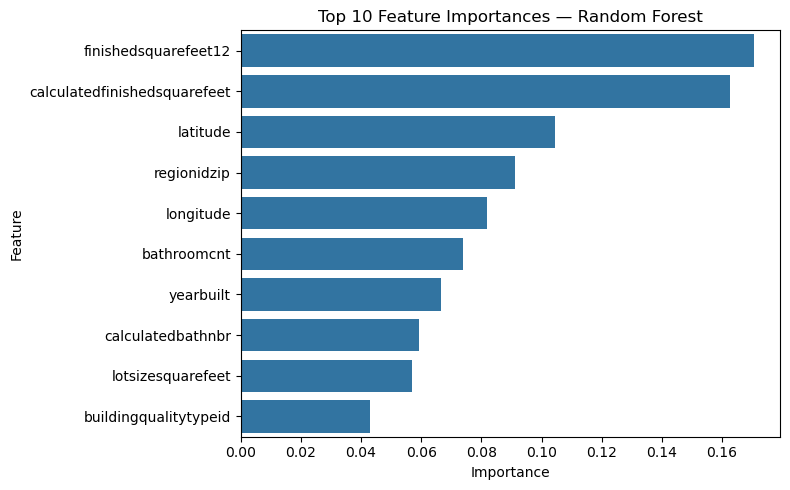

In [6]:
# ============================================
# G) Visual 1 — RF Feature Importance (saved)
# ============================================
rf_model = best_rf.named_steps["model"]

# Names used by numeric selector (these are original numeric col names)
num_cols_used = best_rf.named_steps["pre"].transformers_[0][2]

importances = pd.Series(rf_model.feature_importances_, index=num_cols_used)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("visuals/week6/rf_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

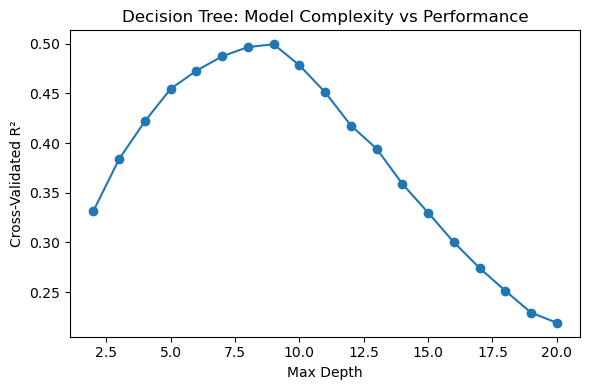

In [7]:
# ==========================================================
# H) Visual 2 — DT complexity curve (depth vs CV R²) (saved)
# ==========================================================
depths = range(2, 21)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
for d in depths:
    dt = Pipeline(steps=[
        ("pre", preprocessor),
        ("model", DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    cv_scores.append(cross_val_score(dt, X_train, y_train, cv=cv, scoring="r2").mean())

plt.figure(figsize=(6,4))
plt.plot(depths, cv_scores, marker="o")
plt.xlabel("Max Depth")
plt.ylabel("Cross-Validated R²")
plt.title("Decision Tree: Model Complexity vs Performance")
plt.tight_layout()
plt.savefig("visuals/week6/tree_depth_cv.png", dpi=200, bbox_inches="tight")
plt.show()

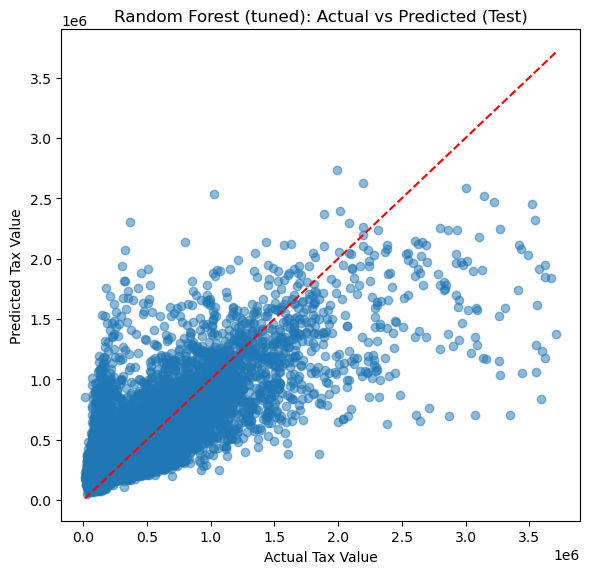

In [8]:
# =================================================
# I) Visual 3 — RF Actual vs Predicted (test) saved
# =================================================
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
min_y, max_y = y_test.min(), y_test.max()
plt.plot([min_y, max_y], [min_y, max_y], "r--")
plt.xlabel("Actual Tax Value")
plt.ylabel("Predicted Tax Value")
plt.title("Random Forest (tuned): Actual vs Predicted (Test)")
plt.tight_layout()
plt.savefig("visuals/week6/rf_actual_vs_pred.png", dpi=200, bbox_inches="tight")
plt.show()

In Week 6, regression tree models were used to predict housing tax values in the Zillow dataset.
A baseline Decision Tree achieved modest accuracy (R² = 0.19), but parameter tuning improved performance to R² = 0.49.
The Random Forest model delivered the strongest results (R² = 0.57, RMSE ≈ $274K), confirming that ensemble methods outperform single estimators by reducing overfitting and capturing more complex data interactions.
Feature importance analysis showed that property size, latitude, longitude, and lot size were the most significant predictors of assessed tax value.
Cross-validation and controlled depth ensured balanced generalization without overfitting.